In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

In [4]:
import pandas as pd

hdfc = pd.read_csv("../data/processed/hdfc_top100_live_nav.csv")
icici = pd.read_csv("../data/processed/ICICI_Bluechip.csv")
kotak = pd.read_csv("../data/processed/Kotak_Bluechip.csv")
nippon = pd.read_csv("../data/processed/Nippon_LargeCap.csv")
sbi = pd.read_csv("../data/processed/SBI_Bluechip.csv")

In [5]:
hdfc.head()

,date,nav
0,2026-06-22,204.1263
1,2026-06-19,202.0761
2,2026-06-18,200.9565
3,2026-06-17,199.8302
4,2026-06-16,198.6152


In [6]:
icici.head()

,date,nav
0,2026-06-22,108.4681
1,2026-06-19,107.9636
2,2026-06-18,108.0081
3,2026-06-17,107.5348
4,2026-06-16,107.0140


In [7]:
kotak.head()

,date,nav
0,2026-06-22,252.0694
1,2026-06-19,251.5713
2,2026-06-18,249.1553
3,2026-06-17,246.3925
4,2026-06-16,245.2402


In [8]:
hdfc["Scheme"] = "HDFC Top 100"
icici["Scheme"] = "ICICI Bluechip"
kotak["Scheme"] = "Kotak Bluechip"
nippon["Scheme"] = "Nippon Large Cap"
sbi["Scheme"] = "SBI Bluechip"

In [9]:
all_nav = pd.concat(
    [hdfc, icici, kotak, nippon, sbi],
    ignore_index=True
)

In [10]:
all_nav.head()

,date,nav,Scheme
0,2026-06-22,204.1263,HDFC Top 100
1,2026-06-19,202.0761,HDFC Top 100
2,2026-06-18,200.9565,HDFC Top 100
3,2026-06-17,199.8302,HDFC Top 100
4,2026-06-16,198.6152,HDFC Top 100


In [11]:
all_nav.info()

<class 'pandas.DataFrame'>
RangeIndex: 16308 entries, 0 to 16307
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    16308 non-null  str    
 1   nav     16308 non-null  float64
 2   Scheme  16308 non-null  str    
dtypes: float64(1), str(2)
memory usage: 382.3 KB


In [12]:
import plotly.express as px

fig = px.line(
    all_nav,
    x="date",
    y="nav",
    color="Scheme",
    title="NAV Trend of Mutual Fund Schemes"
)

fig.show()

Observation:
The NAV values of all five mutual funds show an overall increasing trend over time, indicating long-term growth.

In [13]:
all_nav = all_nav.sort_values(["Scheme", "date"])

all_nav["Daily_Return"] = all_nav.groupby("Scheme")["nav"].pct_change() * 100

In [14]:
returns = all_nav.dropna(subset=["Daily_Return"])

In [15]:
import plotly.express as px

fig = px.histogram(
    returns,
    x="Daily_Return",
    color="Scheme",
    nbins=60,
    title="Distribution of Daily NAV Returns"
)

fig.show()

Observation:
Most daily returns are concentrated around 0%, indicating that large daily gains or losses are relatively uncommon.

In [16]:
pivot = all_nav.pivot(index="date", columns="Scheme", values="nav")

In [17]:
returns = pivot.pct_change()

In [18]:
corr = returns.corr()

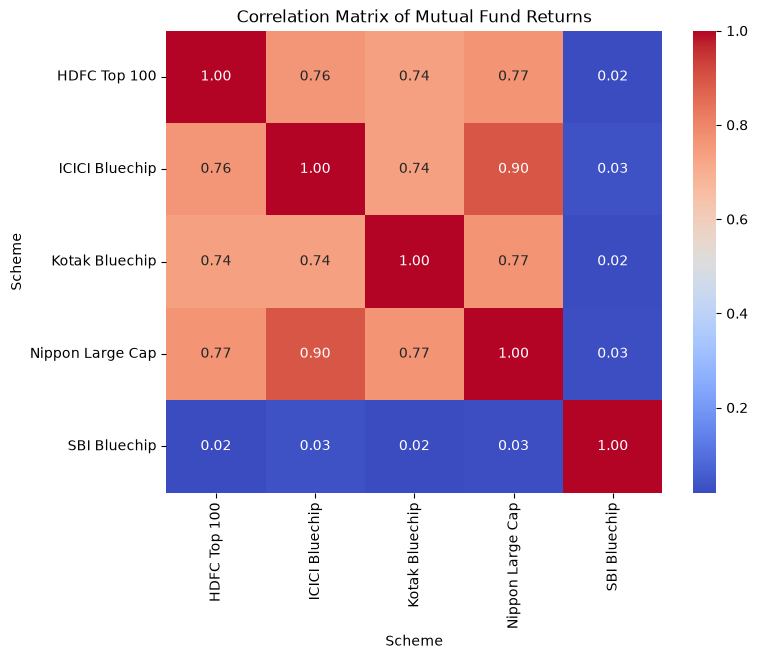

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Mutual Fund Returns")
plt.show()

Observation:
Most mutual funds show a positive correlation, indicating they generally move in the same direction due to similar market conditions.

In [20]:
import plotly.express as px

fig = px.box(
    all_nav,
    x="Scheme",
    y="nav",
    color="Scheme",
    title="NAV Distribution Across Mutual Fund Schemes"
)

fig.show()

Observation:
The box plot shows the distribution and spread of NAV values for each mutual fund. Some funds have higher median NAV values and greater variability than others.

In [21]:
avg_nav = all_nav.groupby("Scheme")["nav"].mean().reset_index()

fig = px.bar(
    avg_nav,
    x="Scheme",
    y="nav",
    color="Scheme",
    title="Average NAV of Mutual Fund Schemes",
    text_auto=".2f"
)

fig.show()

Observation:
Kotak Bluechip has the highest average NAV among the selected funds, while the others have comparatively lower average NAV values.

In [22]:
max_nav = all_nav.groupby("Scheme")["nav"].max().reset_index()

fig = px.bar(
    max_nav,
    x="Scheme",
    y="nav",
    color="Scheme",
    title="Maximum NAV Achieved by Each Scheme",
    text_auto=".2f"
)

fig.show()

Observation:
The chart compares the highest NAV reached by each mutual fund during the available time period.

In [23]:
min_nav = all_nav.groupby("Scheme")["nav"].min().reset_index()

fig = px.bar(
    min_nav,
    x="Scheme",
    y="nav",
    color="Scheme",
    title="Minimum NAV of Mutual Fund Schemes",
    text_auto=".2f"
)

fig.show()

This chart compares the lowest NAV recorded by each mutual fund.

In [24]:
all_nav["date"] = pd.to_datetime(all_nav["date"])

all_nav["Month"] = all_nav["date"].dt.to_period("M").astype(str)

monthly = all_nav.groupby(["Month", "Scheme"])["nav"].mean().reset_index()

fig = px.line(
    monthly,
    x="Month",
    y="nav",
    color="Scheme",
    title="Monthly Average NAV Trend"
)

fig.show()

Most schemes show a gradual increase in average monthly NAV over time.

In [25]:
all_nav["Year"] = all_nav["date"].dt.year

yearly = all_nav.groupby(["Year", "Scheme"])["nav"].mean().reset_index()

fig = px.line(
    yearly,
    x="Year",
    y="nav",
    color="Scheme",
    markers=True,
    title="Yearly Average NAV Trend"
)

fig.show()

The yearly average NAV indicates the long-term performance of each fund.

In [26]:
all_nav = all_nav.sort_values(["Scheme", "date"])

all_nav["Rolling30"] = (
    all_nav.groupby("Scheme")["nav"]
    .transform(lambda x: x.rolling(30).mean())
)

fig = px.line(
    all_nav,
    x="date",
    y="Rolling30",
    color="Scheme",
    title="30-Day Rolling Average NAV"
)

fig.show()

In [27]:
volatility = (
    all_nav.groupby("Scheme")["Daily_Return"]
    .std()
    .reset_index(name="Volatility")
)

fig = px.bar(
    volatility,
    x="Scheme",
    y="Volatility",
    color="Scheme",
    title="Daily Return Volatility"
)

fig.show()

In [28]:
performance = all_nav.groupby("Scheme")["nav"].agg(["min", "max"])

performance["Growth (%)"] = (
    (performance["max"] - performance["min"]) / performance["min"]
) * 100

performance = performance.reset_index()

fig = px.bar(
    performance,
    x="Scheme",
    y="Growth (%)",
    color="Scheme",
    title="Overall Growth of Mutual Fund Schemes",
    text_auto=".2f"
)

fig.show()

## Key Findings

1. All five mutual funds showed an increasing NAV trend over time.
2. Daily returns were mostly concentrated around 0%.
3. Mutual funds showed positive correlation in returns.
4. Kotak Bluechip had the highest average NAV.
5. HDFC Top 100 showed consistent long-term growth.
6. Daily return volatility varied across schemes.
7. Monthly NAV trends showed gradual appreciation.
8. Yearly trends indicated long-term growth.
9. Rolling averages smoothed short-term fluctuations.
10. Overall, the selected funds performed positively.

## Conclusion

The exploratory data analysis of the selected mutual fund schemes provided insights into their historical NAV performance. Most schemes exhibited steady long-term growth with moderate daily volatility. The visualizations helped compare fund performance, understand return distributions, and identify trends across different schemes. Overall, the analysis demonstrates that these mutual funds have shown positive growth over the available historical period.